# Dropout
Dropout[1]是一种通过在前向传递过程中随机将一些输出激活设置为零来正则化神经网络的技术。在本练习中，您将实现一个Dropout层，并修改您的全连接网络以选择性地使用Dropout。

[1] [Geoffrey E. Hinton et al, "Improving neural networks by preventing co-adaptation of feature detectors", arXiv 2012](https://arxiv.org/abs/1207.0580)

In [1]:
# Setup cell.
import time
import numpy as np
import matplotlib.pyplot as plt
from dlcv.classifiers.fc_net import *
from dlcv.data_utils import get_CIFAR10_data
from dlcv.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from dlcv.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [2]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


In [3]:
test=np.random.rand(4,4)<0.5
print(test)

[[ True  True False False]
 [False  True False False]
 [ True  True  True  True]
 [False False  True  True]]


# Dropout: Forward Pass
在文件“dlcv / layers.py”,实现dropout的前向传递。由于dropout在训练和测试期间的行为不同，请确保为两种模式实现操作。

完成后，运行下面的单元格来测试你的实现。

In [4]:
np.random.seed(231)
x = np.random.randn(500, 500) + 10

for p in [0.25, 0.4, 0.7]:
    out, _ = dropout_forward(x, {'mode': 'train', 'p': p})
    out_test, _ = dropout_forward(x, {'mode': 'test', 'p': p})
    print('Running tests with p = ', p)
    print('Mean of input: ', x.mean())
    print('Mean of train-time output: ', out.mean())
    print('Mean of test-time output: ', out_test.mean())
    print('Fraction of train-time output set to zero: ', (out == 0).mean())
    print('Fraction of test-time output set to zero: ', (out_test == 0).mean())
    print()

Running tests with p =  0.25
Mean of input:  10.0002078784775
Mean of train-time output:  10.014059116977283
Mean of test-time output:  10.0002078784775
Fraction of train-time output set to zero:  0.749784
Fraction of test-time output set to zero:  0.0

Running tests with p =  0.4
Mean of input:  10.0002078784775
Mean of train-time output:  9.977917658761159
Mean of test-time output:  10.0002078784775
Fraction of train-time output set to zero:  0.600796
Fraction of test-time output set to zero:  0.0

Running tests with p =  0.7
Mean of input:  10.0002078784775
Mean of train-time output:  9.987811912159428
Mean of test-time output:  10.0002078784775
Fraction of train-time output set to zero:  0.30074
Fraction of test-time output set to zero:  0.0



# Dropout: Backward Pass
在文件`dlcv/layers.py`中，实现dropout的反向传递。完成之后，运行下面的单元格来进行数值渐变——检查你的实现。

In [5]:
np.random.seed(231)
x = np.random.randn(10, 10) + 10
dout = np.random.randn(*x.shape)

dropout_param = {'mode': 'train', 'p': 0.2, 'seed': 123}
out, cache = dropout_forward(x, dropout_param)
dx = dropout_backward(dout, cache)
dx_num = eval_numerical_gradient_array(lambda xx: dropout_forward(xx, dropout_param)[0], x, dout)

# Error should be around e-10 or less.
print('dx relative error: ', rel_error(dx, dx_num))

dx relative error:  1.8928938043362133e-11


## Inline Question 1:
如果我们不将通过逆dropout传递的值除以dropout层中的`p`，会发生什么?为什么会这样呢?

## Answer:
如果在倒置 dropout 中不把被保留的激活除以 p，训练时每层的激活期望会变成原来的 p 倍（因为只有概率 p 被保留），导致训练时网络看到的数值分布与测试时（没有 dropout）不一致：测试阶段激活值会比训练阶段大约多 1/p 倍，从而引起预测偏移并影响梯度规模和收敛行为；简言之，会产生训练/测试分布不匹配并使学习困难。


# Fully Connected Networks with Dropout
在文件`dlcv/classifiers/fc_net.py`中，修改你的实现以使用dropout。具体来说，如果网络的构造函数接收到一个不为1的`dropout_keep_ratio`参数值，那么网络应该在每次ReLU非线性之后立即添加一个dropout层。这样做之后,运行以下代码来进行数值梯度——检查你的实现。

In [6]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for dropout_keep_ratio in [1, 0.75, 0.5]:
    print('Running check with dropout = ', dropout_keep_ratio)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        weight_scale=5e-2,
        dtype=np.float64,
        dropout_keep_ratio=dropout_keep_ratio,
        seed=123
    )

    loss, grads = model.loss(X, y)
    print('Initial loss: ', loss)

    # Relative errors should be around e-6 or less.
    # Note that it's fine if for dropout_keep_ratio=1 you have W2 error be on the order of e-5.
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))
    print()

Running check with dropout =  1
Initial loss:  2.300479089768492
W1 relative error: 1.03e-07
W2 relative error: 2.21e-05
W3 relative error: 4.56e-07
b1 relative error: 4.66e-09
b2 relative error: 2.09e-09
b3 relative error: 1.69e-10

Running check with dropout =  0.75
Initial loss:  2.302371489704412
W1 relative error: 1.85e-07
W2 relative error: 2.15e-06
W3 relative error: 4.56e-08
b1 relative error: 1.16e-08
b2 relative error: 1.82e-09
b3 relative error: 1.48e-10

Running check with dropout =  0.5
Initial loss:  2.30427592207859
W1 relative error: 3.11e-07
W2 relative error: 2.48e-08
W3 relative error: 6.43e-08
b1 relative error: 5.37e-09
b2 relative error: 1.91e-09
b3 relative error: 1.85e-10



# Regularization Experiment
作为实验，我们将在500个训练示例上训练一对两层网络:一个将不使用dropout，一个将使用保持概率为0.25。然后，我们将随着时间的推移可视化两个网络的训练和验证精度。

In [7]:
# Train two identical nets, one with dropout and one without.
np.random.seed(231)
num_train = 500
small_data = {
    'X_train': data['X_train'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val': data['X_val'],
    'y_val': data['y_val'],
}

solvers = {}
dropout_choices = [1, 0.25]
for dropout_keep_ratio in dropout_choices:
    model = FullyConnectedNet(
        [500],
        dropout_keep_ratio=dropout_keep_ratio
    )
    print(dropout_keep_ratio)

    solver = Solver(
        model,
        small_data,
        num_epochs=25,
        batch_size=100,
        update_rule='adam',
        optim_config={'learning_rate': 5e-4,},
        verbose=True,
        print_every=100
    )
    solver.train()
    solvers[dropout_keep_ratio] = solver
    print()

1
(Iteration 1 / 125) loss: 7.856643
(Epoch 0 / 25) train acc: 0.260000; val_acc: 0.184000
(Epoch 1 / 25) train acc: 0.416000; val_acc: 0.258000
(Epoch 2 / 25) train acc: 0.482000; val_acc: 0.276000
(Epoch 3 / 25) train acc: 0.532000; val_acc: 0.277000
(Epoch 4 / 25) train acc: 0.600000; val_acc: 0.271000
(Epoch 5 / 25) train acc: 0.708000; val_acc: 0.299000
(Epoch 6 / 25) train acc: 0.722000; val_acc: 0.282000
(Epoch 7 / 25) train acc: 0.832000; val_acc: 0.255000
(Epoch 8 / 25) train acc: 0.880000; val_acc: 0.268000
(Epoch 9 / 25) train acc: 0.902000; val_acc: 0.277000
(Epoch 10 / 25) train acc: 0.898000; val_acc: 0.261000
(Epoch 11 / 25) train acc: 0.924000; val_acc: 0.263000
(Epoch 12 / 25) train acc: 0.960000; val_acc: 0.300000
(Epoch 13 / 25) train acc: 0.972000; val_acc: 0.315000
(Epoch 14 / 25) train acc: 0.972000; val_acc: 0.311000
(Epoch 15 / 25) train acc: 0.972000; val_acc: 0.317000
(Epoch 16 / 25) train acc: 0.994000; val_acc: 0.309000
(Epoch 17 / 25) train acc: 0.974000; v

e:\trAshbaGrepository\CV\dlcv\layers.py:1198: RuntimeWarning: divide by zero encountered in log
  correct_log_probs = -np.log(probs[np.arange(N), y])


(Epoch 2 / 25) train acc: 0.402000; val_acc: 0.254000
(Epoch 3 / 25) train acc: 0.502000; val_acc: 0.276000
(Epoch 4 / 25) train acc: 0.528000; val_acc: 0.298000
(Epoch 5 / 25) train acc: 0.562000; val_acc: 0.296000
(Epoch 6 / 25) train acc: 0.620000; val_acc: 0.290000
(Epoch 7 / 25) train acc: 0.628000; val_acc: 0.298000
(Epoch 8 / 25) train acc: 0.676000; val_acc: 0.310000
(Epoch 9 / 25) train acc: 0.718000; val_acc: 0.293000
(Epoch 10 / 25) train acc: 0.730000; val_acc: 0.307000
(Epoch 11 / 25) train acc: 0.752000; val_acc: 0.309000
(Epoch 12 / 25) train acc: 0.764000; val_acc: 0.294000
(Epoch 13 / 25) train acc: 0.818000; val_acc: 0.313000
(Epoch 14 / 25) train acc: 0.816000; val_acc: 0.348000
(Epoch 15 / 25) train acc: 0.860000; val_acc: 0.348000
(Epoch 16 / 25) train acc: 0.850000; val_acc: 0.312000
(Epoch 17 / 25) train acc: 0.858000; val_acc: 0.300000
(Epoch 18 / 25) train acc: 0.850000; val_acc: 0.313000
(Epoch 19 / 25) train acc: 0.884000; val_acc: 0.316000
(Epoch 20 / 25) tr

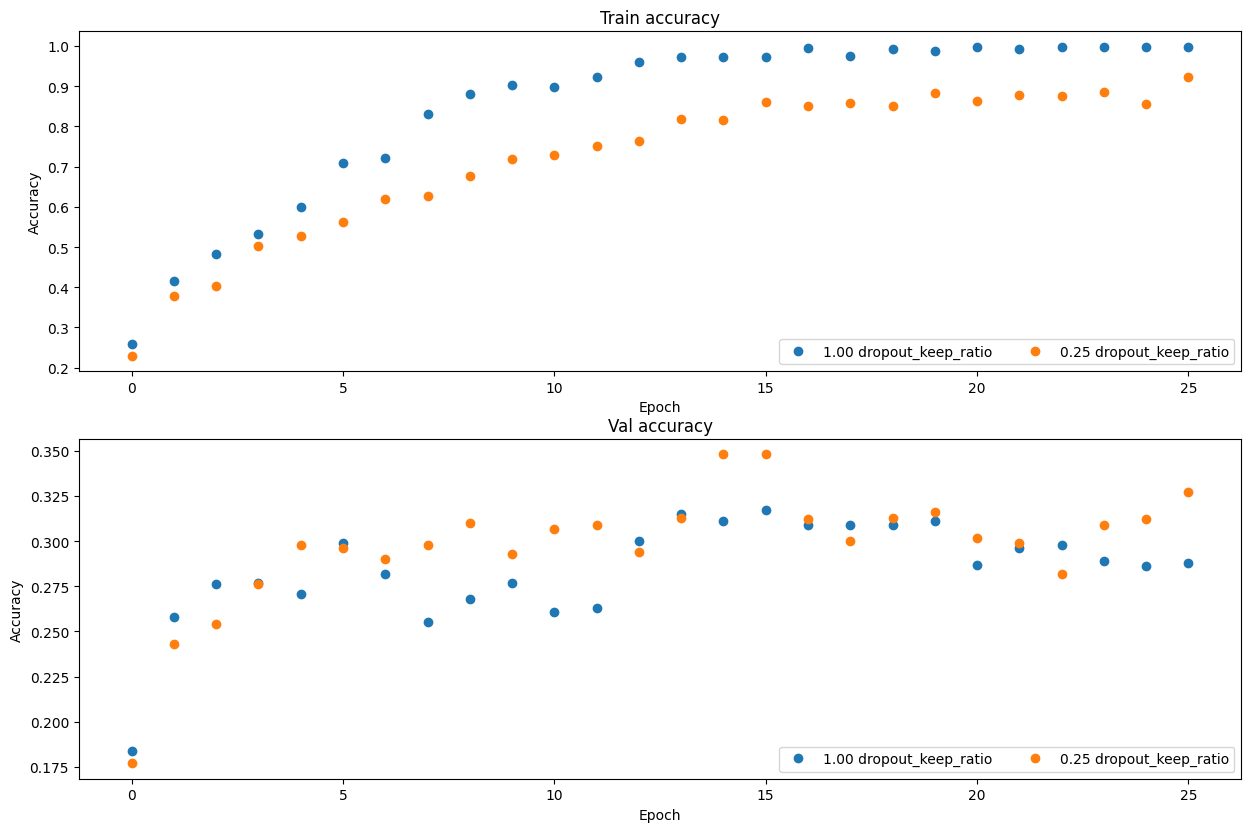

In [8]:
# Plot train and validation accuracies of the two models.
train_accs = []
val_accs = []
for dropout_keep_ratio in dropout_choices:
    solver = solvers[dropout_keep_ratio]
    train_accs.append(solver.train_acc_history[-1])
    val_accs.append(solver.val_acc_history[-1])

plt.subplot(3, 1, 1)
for dropout_keep_ratio in dropout_choices:
    plt.plot(
        solvers[dropout_keep_ratio].train_acc_history, 'o', label='%.2f dropout_keep_ratio' % dropout_keep_ratio)
plt.title('Train accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(ncol=2, loc='lower right')
  
plt.subplot(3, 1, 2)
for dropout_keep_ratio in dropout_choices:
    plt.plot(
        solvers[dropout_keep_ratio].val_acc_history, 'o', label='%.2f dropout_keep_ratio' % dropout_keep_ratio)
plt.title('Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(ncol=2, loc='lower right')

plt.gcf().set_size_inches(15, 15)
plt.show()

## Inline Question 2:
比较有dropout和没有dropout时的验证精度和训练精度——关于dropout作为正则化器，您的结果表明了什么?

## Answer:
有 dropout 的网络通常在训练精度上低于不使用 dropout 的网络（因为训练时随机丢弃一部分神经元会限制模型对训练数据的拟合能力），但在验证集上的精度通常更高或更稳定：这是因为 dropout 起到正则化作用，减少了网络对训练数据的过拟合，迫使模型学习更鲁棒、分散的特征表示。换言之，dropout 可以提升泛化性能，但代价是训练时收敛更慢、训练精度较低；因此需要通过调整保持概率、学习率和训练轮数等超参数来取得最佳平衡。